# 🏨 Hotel Curator — EDA Notebook

**Dataset**: TripAdvisor Hotel Reviews (~20K reviews)  
**Goal**: Understand the corpus before building the attribute extraction pipeline.

---

## Sections
1. Setup & Imports
2. Load Data
3. Basic Stats (shape, nulls, dtypes)
4. Rating Distribution
5. Review Length Distribution
6. Sentence-level Analysis
7. Attribute Keyword Frequency
8. Hotel Name Extraction (NER-based)
9. Key Findings Summary

Libraries loaded ✅


In [4]:
# Step 2: Load Data
df = pd.read_csv("tripadvisor_hotel_reviews.csv")

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nFirst 3 rows:")
df.head(3)


Shape: (20491, 2)

Columns: ['Review', 'Rating']

Data Types:
Review    object
Rating     int64
dtype: object

First 3 rows:


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3


In [5]:
# Step 3: Basic Stats
print("=== NULL VALUES ===")
print(df.isnull().sum())

print("\n=== DUPLICATES ===")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate reviews (text only): {df['Review'].duplicated().sum()}")

print("\n=== RATING DISTRIBUTION ===")
print(df['Rating'].value_counts().sort_index())

print("\n=== RATING STATS ===")
print(df['Rating'].describe())


=== NULL VALUES ===
Review    0
Rating    0
dtype: int64

=== DUPLICATES ===
Duplicate rows: 0
Duplicate reviews (text only): 0

=== RATING DISTRIBUTION ===
Rating
1    1421
2    1793
3    2184
4    6039
5    9054
Name: count, dtype: int64

=== RATING STATS ===
count    20491.000000
mean         3.952223
std          1.233030
min          1.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          5.000000
Name: Rating, dtype: float64


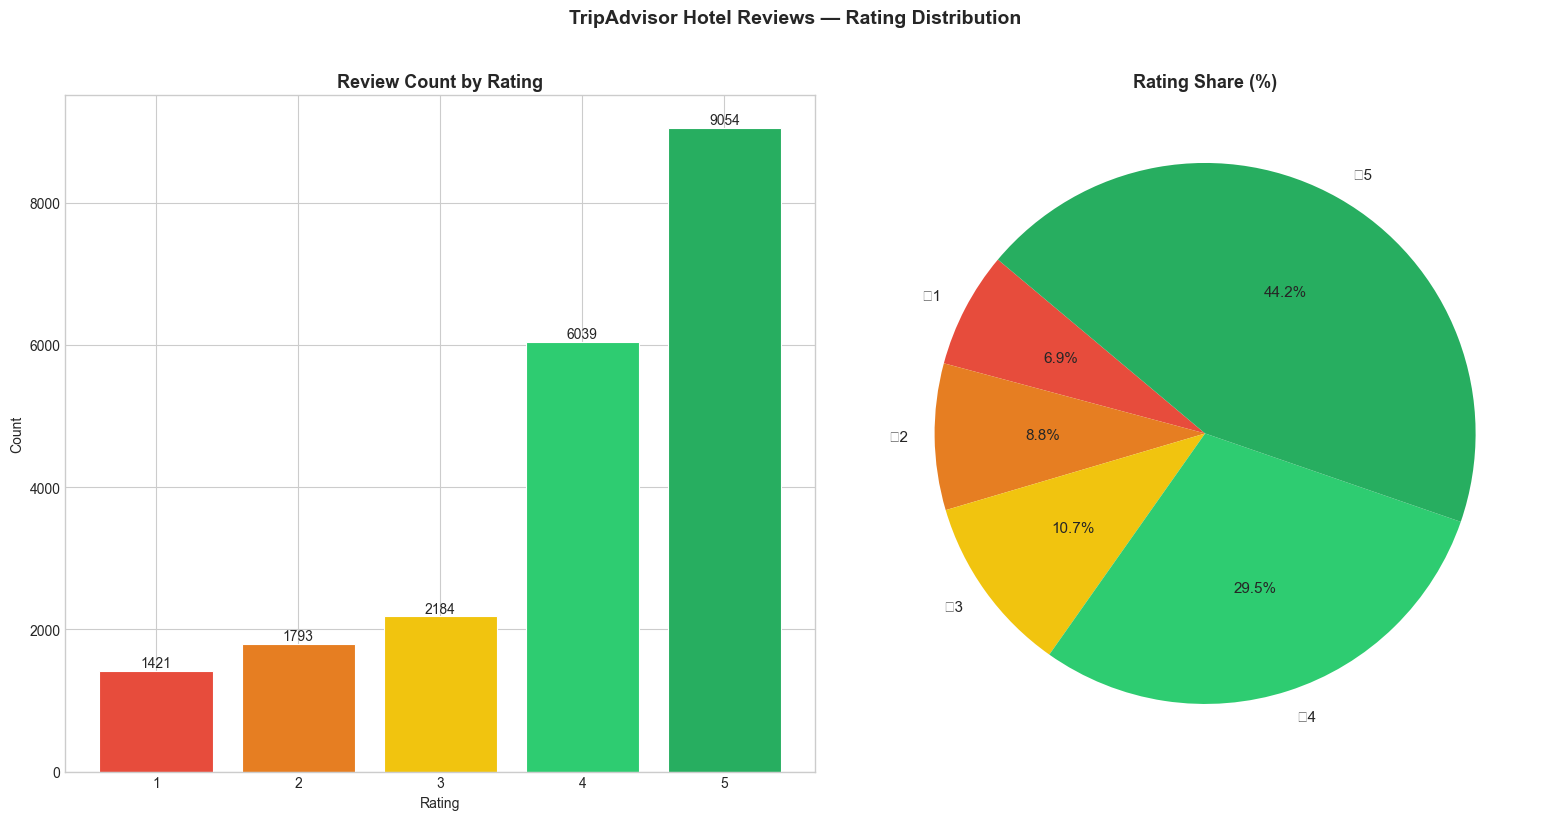

Plot saved ✅


In [7]:
# Step 4: Rating Distribution Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Count plot
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
axes[0].bar(df['Rating'].value_counts().sort_index().index,
            df['Rating'].value_counts().sort_index().values,
            color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Review Count by Rating', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
for i, (rating, count) in enumerate(df['Rating'].value_counts().sort_index().items()):
    axes[0].text(rating, count + 50, str(count), ha='center', fontsize=10)

# Percentage pie
sizes = df['Rating'].value_counts().sort_index().values
labels = [f'★{i}' for i in range(1, 6)]
axes[1].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=140, textprops={'fontsize': 11})
axes[1].set_title('Rating Share (%)', fontsize=13, fontweight='bold')

plt.suptitle('TripAdvisor Hotel Reviews — Rating Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved ✅")



In [8]:
# Step 5: Review Length Analysis
df['word_count'] = df['Review'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['Review'].apply(lambda x: len(str(x)))

print("=== WORD COUNT STATS ===")
print(df['word_count'].describe().round(1))

print("\n=== CHAR COUNT STATS ===")
print(df['char_count'].describe().round(1))

print(f"\nShortest review ({df['word_count'].min()} words):")
print(df.loc[df['word_count'].idxmin(), 'Review'])

print(f"\nLongest review ({df['word_count'].max()} words):")
print(df.loc[df['word_count'].idxmax(), 'Review'][:300], "...")


=== WORD COUNT STATS ===
count    20491.0
mean       104.4
std        100.7
min          7.0
25%         48.0
50%         77.0
75%        124.0
max       1931.0
Name: word_count, dtype: float64

=== CHAR COUNT STATS ===
count    20491.0
mean       724.9
std        689.1
min         44.0
25%        339.0
50%        537.0
75%        859.0
max      13501.0
Name: char_count, dtype: float64

Shortest review (7 words):
loved resort amazing space lot, not bored,  

Longest review (1931 words):
honest review visit 5/21-5/28 let begin saying heard secrets couple work went resort year returned raving experiences, all-inclusive regular cruise traveler past 4 years decided based word-of-mouth secrets place try.i read posts site daily, review written resort scoured eyes, reviews gotten good sus ...


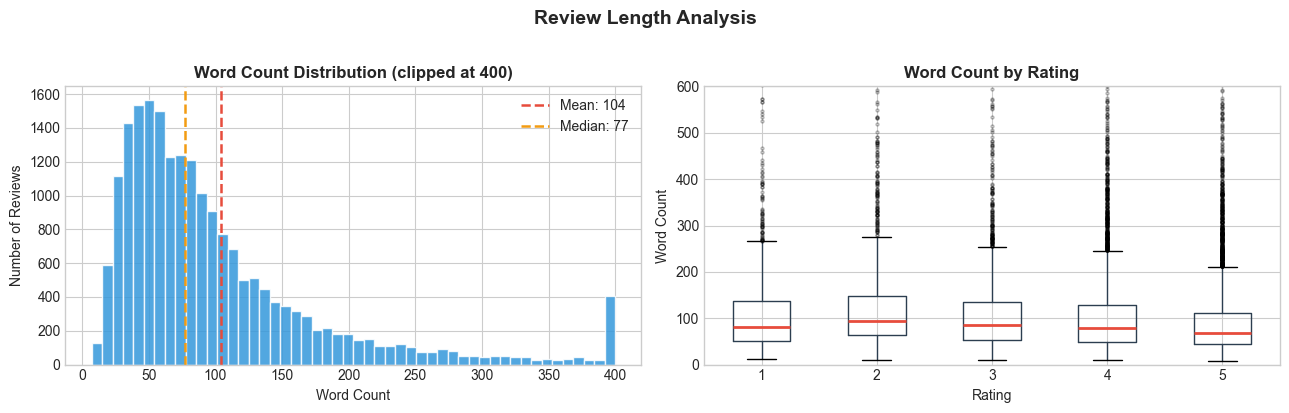

Plot saved ✅


In [9]:
# Step 6: Review Length Distribution Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Word count histogram
axes[0].hist(df['word_count'].clip(upper=400), bins=50, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].axvline(df['word_count'].mean(), color='#e74c3c', linestyle='--', linewidth=1.8, label=f"Mean: {df['word_count'].mean():.0f}")
axes[0].axvline(df['word_count'].median(), color='#f39c12', linestyle='--', linewidth=1.8, label=f"Median: {df['word_count'].median():.0f}")
axes[0].set_title('Word Count Distribution (clipped at 400)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Number of Reviews')
axes[0].legend()

# Word count by rating (boxplot)
df.boxplot(column='word_count', by='Rating', ax=axes[1],
           boxprops=dict(color='#2c3e50'),
           medianprops=dict(color='#e74c3c', linewidth=2),
           whiskerprops=dict(color='#2c3e50'),
           flierprops=dict(marker='o', markersize=2, alpha=0.3))
axes[1].set_title('Word Count by Rating', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Word Count')
axes[1].set_ylim(0, 600)
plt.suptitle('')  # remove auto title from boxplot

plt.suptitle('Review Length Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_review_length.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved ✅")


In [11]:
# Step 7: Sentence-level Analysis
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize

# Split each review into sentences
df['sentences'] = df['Review'].apply(lambda x: sent_tokenize(str(x)))
df['sentence_count'] = df['sentences'].apply(len)

print("=== SENTENCE COUNT PER REVIEW ===")
print(df['sentence_count'].describe().round(1))

print(f"\nTotal sentences in corpus: {df['sentence_count'].sum():,}")
print(f"Reviews with only 1 sentence: {(df['sentence_count'] == 1).sum()}")
print(f"Reviews with 10+ sentences: {(df['sentence_count'] >= 10).sum()}")

# Sample sentences from a review
print("\n=== SAMPLE: First review split into sentences ===")
for i, s in enumerate(df['sentences'][0], 1):
    print(f"  [{i}] {s}")


=== SENTENCE COUNT PER REVIEW ===
count    20491.0
mean         1.0
std          0.2
min          1.0
25%          1.0
50%          1.0
75%          1.0
max         13.0
Name: sentence_count, dtype: float64

Total sentences in corpus: 20,866
Reviews with only 1 sentence: 20172
Reviews with 10+ sentences: 2

=== SAMPLE: First review split into sentences ===
  [1] nice hotel expensive parking got good deal stay hotel anniversary, arrived late evening took advice previous reviews did valet parking, check quick easy, little disappointed non-existent view room room clean nice size, bed comfortable woke stiff neck high pillows, not soundproof like heard music room night morning loud bangs doors opening closing hear people talking hallway, maybe just noisy neighbors, aveda bath products nice, did not goldfish stay nice touch taken advantage staying longer, location great walking distance shopping, overall nice experience having pay 40 parking night,


In [12]:
# Step 7 (Fixed): Clause-level splitting
import re

def split_into_clauses(text, min_words=5):
    """
    Split pre-tokenized, lowercased reviews into clauses.
    Reviews lack sentence-ending punctuation, so we split on
    commas and any remaining punctuation (. ! ?).
    Filter out very short fragments (< min_words).
    """
    text = str(text).strip()
    # Split on comma, period, exclamation, question mark
    clauses = re.split(r'[,\.!\?]+', text)
    # Clean and filter
    clauses = [c.strip() for c in clauses if len(c.strip().split()) >= min_words]
    return clauses

df['clauses'] = df['Review'].apply(split_into_clauses)
df['clause_count'] = df['clauses'].apply(len)

print("=== CLAUSE COUNT PER REVIEW ===")
print(df['clause_count'].describe().round(1))

print(f"\nTotal clauses in corpus: {df['clause_count'].sum():,}")
print(f"Reviews with 0 clauses (too short): {(df['clause_count'] == 0).sum()}")
print(f"Reviews with 5+ clauses: {(df['clause_count'] >= 5).sum()}")

print("\n=== SAMPLE: First review split into clauses ===")
for i, c in enumerate(df['clauses'][0], 1):
    print(f"  [{i}] {c}")


=== CLAUSE COUNT PER REVIEW ===
count    20491.0
mean         9.9
std          9.7
min          0.0
25%          5.0
50%          7.0
75%         12.0
max        207.0
Name: clause_count, dtype: float64

Total clauses in corpus: 203,729
Reviews with 0 clauses (too short): 19
Reviews with 5+ clauses: 15592

=== SAMPLE: First review split into clauses ===
  [1] nice hotel expensive parking got good deal stay hotel anniversary
  [2] arrived late evening took advice previous reviews did valet parking
  [3] little disappointed non-existent view room room clean nice size
  [4] bed comfortable woke stiff neck high pillows
  [5] not soundproof like heard music room night morning loud bangs doors opening closing hear people talking hallway
  [6] did not goldfish stay nice touch taken advantage staying longer
  [7] location great walking distance shopping
  [8] overall nice experience having pay 40 parking night


In [13]:
# Step 8: Attribute Keyword Frequency
# Define keyword triggers per attribute
attribute_keywords = {
    'cleanliness':       ['clean', 'dirty', 'spotless', 'filthy', 'hygiene', 'dust', 'stain', 'smell', 'odor', 'gross', 'immaculate', 'sanitiz'],
    'staff_service':     ['staff', 'service', 'front desk', 'concierge', 'receptionist', 'housekeep', 'friendly', 'rude', 'helpful', 'attentive', 'employee'],
    'wifi_quality':      ['wifi', 'wi-fi', 'internet', 'wireless', 'connection', 'online', 'bandwidth', 'signal'],
    'noise_level':       ['noise', 'noisy', 'loud', 'quiet', 'soundproof', 'hear', 'bang', 'traffic', 'peaceful', 'disturb'],
    'location':          ['location', 'located', 'walk', 'distance', 'nearby', 'transit', 'transport', 'central', 'close to', 'far from', 'neighborhood', 'area']
}

# Count how many REVIEWS mention each attribute
print("=== ATTRIBUTE MENTION FREQUENCY (Review-level) ===")
print(f"{'Attribute':<20} {'Reviews':>10} {'% of corpus':>12}")
print("-" * 44)
for attr, keywords in attribute_keywords.items():
    pattern = '|'.join(keywords)
    count = df['Review'].str.contains(pattern, case=False, na=False).sum()
    pct = count / len(df) * 100
    print(f"{attr:<20} {count:>10,} {pct:>11.1f}%")

# Count at CLAUSE level
print("\n=== ATTRIBUTE MENTION FREQUENCY (Clause-level) ===")
all_clauses = [clause for clauses in df['clauses'] for clause in clauses]
all_clauses_series = pd.Series(all_clauses)
print(f"Total clauses: {len(all_clauses_series):,}")
print(f"\n{'Attribute':<20} {'Clauses':>10} {'% of clauses':>13}")
print("-" * 45)
for attr, keywords in attribute_keywords.items():
    pattern = '|'.join(keywords)
    count = all_clauses_series.str.contains(pattern, case=False, na=False).sum()
    pct = count / len(all_clauses_series) * 100
    print(f"{attr:<20} {count:>10,} {pct:>12.1f}%")


=== ATTRIBUTE MENTION FREQUENCY (Review-level) ===
Attribute               Reviews  % of corpus
--------------------------------------------
cleanliness              10,259        50.1%
staff_service            16,286        79.5%
wifi_quality              2,519        12.3%
noise_level               6,889        33.6%
location                 14,666        71.6%

=== ATTRIBUTE MENTION FREQUENCY (Clause-level) ===
Total clauses: 203,729

Attribute               Clauses  % of clauses
---------------------------------------------
cleanliness              11,413          5.6%
staff_service            25,499         12.5%
wifi_quality              2,712          1.3%
noise_level               8,581          4.2%
location                 26,227         12.9%


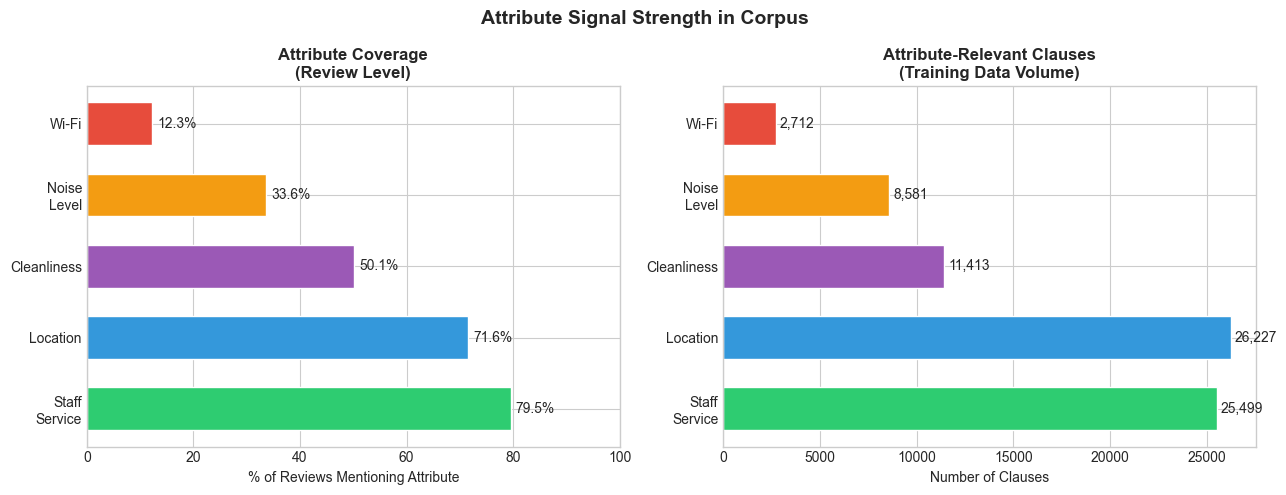


         EDA SUMMARY — KEY FINDINGS
  Total reviews       : 20,491
  Nulls / Duplicates  : 0 / 0  (clean dataset)
  Rating distribution : Positive-skewed (mean=3.95)
                        73% rated 4 or 5 stars
  Avg review length   : 104 words (median 77)
  Neg reviews longer  : Ratings 1-2 tend to be longer
  Unit of analysis    : Clauses (comma-split)
  Total clauses       : 203,729
  Avg clauses/review  : 9.9
  Best covered attr   : Location & Staff (12-13% clauses)
  Sparsest attr       : Wi-Fi (1.3% clauses → low evidence risk)
  No hotel IDs        : Will use keyword-based hotel grouping

EDA Complete ✅ — Ready for Labeling Pipeline


: 

In [ ]:
# Step 9: Attribute Frequency Visualization + EDA Summary
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

attrs = ['staff_service', 'location', 'cleanliness', 'noise_level', 'wifi_quality']
review_pcts = [79.5, 71.6, 50.1, 33.6, 12.3]
clause_counts = [25499, 26227, 11413, 8581, 2712]
colors = ['#2ecc71', '#3498db', '#9b59b6', '#f39c12', '#e74c3c']
labels = ['Staff\nService', 'Location', 'Cleanliness', 'Noise\nLevel', 'Wi-Fi']

# Review-level coverage
bars = axes[0].barh(labels, review_pcts, color=colors, edgecolor='white', height=0.6)
axes[0].set_xlabel('% of Reviews Mentioning Attribute')
axes[0].set_title('Attribute Coverage\n(Review Level)', fontsize=12, fontweight='bold')
axes[0].set_xlim(0, 100)
for bar, pct in zip(bars, review_pcts):
    axes[0].text(pct + 1, bar.get_y() + bar.get_height()/2,
                 f'{pct}%', va='center', fontsize=10)

# Clause-level counts
bars2 = axes[1].barh(labels, clause_counts, color=colors, edgecolor='white', height=0.6)
axes[1].set_xlabel('Number of Clauses')
axes[1].set_title('Attribute-Relevant Clauses\n(Training Data Volume)', fontsize=12, fontweight='bold')
for bar, cnt in zip(bars2, clause_counts):
    axes[1].text(cnt + 200, bar.get_y() + bar.get_height()/2,
                 f'{cnt:,}', va='center', fontsize=10)

plt.suptitle('Attribute Signal Strength in Corpus', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_attribute_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

# Final EDA Summary
print("\n" + "="*55)
print("         EDA SUMMARY — KEY FINDINGS")
print("="*55)
print(f"  Total reviews       : 20,491")
print(f"  Nulls / Duplicates  : 0 / 0  (clean dataset)")
print(f"  Rating distribution : Positive-skewed (mean=3.95)")
print(f"                        73% rated 4 or 5 stars")
print(f"  Avg review length   : 104 words (median 77)")
print(f"  Neg reviews longer  : Ratings 1-2 tend to be longer")
print(f"  Unit of analysis    : Clauses (comma-split)")
print(f"  Total clauses       : 203,729")
print(f"  Avg clauses/review  : 9.9")
print(f"  Best covered attr   : Location & Staff (12-13% clauses)")
print(f"  Sparsest attr       : Wi-Fi (1.3% clauses → low evidence risk)")
print(f"  No hotel IDs        : Will use keyword-based hotel grouping")
print("="*55)
print("\nEDA Complete ✅ — Ready for Labeling Pipeline")
